# Policy retrieval, measured

ArchCompass reviews a repository by showing a language model one *candidate* — a structural
shape a detector found, such as an interface with exactly one implementation — together with
the architectural policies that bear on it, and asking it to judge the one against the other.

It cannot show all 54 policies every time. That is a large prompt for every candidate in
every review, and most of the corpus is irrelevant to any particular one. So a **retriever**
picks about twenty. Everything the review then concludes is bounded by that pick: a policy
the retriever left out cannot be weighed, argued with or cited, however good the model is.

This notebook measures how good the pick is.

### How the retriever works

1. **Embedding.** An embedding model reads a piece of text and returns 768 numbers — a point
   in a 768-dimensional space. It is trained so that texts which *mean* similar things land
   near each other even when they share no words. "the ingestion queue has no size limit" and
   "bound every queue and answer overload with backpressure" have almost nothing in common
   lexically, and sit close together in this space.
2. **Indexing.** Every policy is split at its `## ` headings and each piece is embedded once,
   up front. 54 policies become 486 points, stored in SQLite.
3. **Searching.** A candidate is turned into a query string, embedded the same way, and the
   corpus is sorted by how close each point is to it — cosine similarity, which compares the
   *direction* of two vectors and ignores their length. The top twenty policies go into the
   prompt.

The embedding model is **`embeddinggemma`**, a 300M-parameter model from Google running
locally on Ollama. Nothing here calls a hosted service or a reasoning model.

**To run it:** `ollama pull embeddinggemma`, then `make evaluation`. Two minutes from cold.

How the test set is built, and how to add to it, is in [`evaluation/README.md`](README.md).

## The short version

The headline number is **recall@20**: *of the policies that should have been retrieved for a
case, what share actually landed in the top twenty?* 0.897 means about nine in ten.

| | |
|---|---|
| Recall@20 | **0.897** — against 0.853 for a keyword search and 0.353 for picking at random |
| Strongest on | duplicated-knowledge and scattered-concept candidates, both **1.00** |
| Weakest on | sole-implementation candidates, **0.735** |
| Release gate | **fails at every K** — macro recall caps at 0.839 against a floor of 0.95 |
| Why it fails | one policy, `design-for-replaceability`, missed on 9 cases at a **median rank of 44 of 54** |
| Free improvement available | EmbeddingGemma's task prompts: MRR 0.730 → **0.775**, unused today |
| Cost | ~125 ms a query, of which under 1% is the search — it is all the embedding call |

The gate failure is not a regression. `evaluation.yaml`, the file the gate reads, did not
exist in this repository until this notebook wrote one — so K=20 was chosen without a
labelled set to check it against. This is the gate's first real verdict.

The interesting part is *why* it fails. Nine of the fourteen misses are a single policy that
lands near the bottom of the corpus for exactly the queries it was written to answer. That is
a sentence missing from a document, not a constant that needs raising. Section 4 shows it.

---

In [1]:
# The repository root, found rather than assumed: Jupyter's working directory depends on
# where it was launched from. This cell runs alone because nothing under `evaluation` is
# importable until it has.
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(ROOT)

/Users/furkan/Documents/arch_compass


In [2]:
import json
import sqlite3
import time

import httpx
import pandas as pd
import yaml

from archcompass.policies.adapters import SQLitePolicyIndex
from archcompass.policies.evaluation import choose_smallest_passing_k, evaluate_retrieval
from evaluation.harness import (
    Bm25PolicyIndex,
    InMemoryDenseIndex,
    RandomPolicyIndex,
    TaskPrefixedEmbeddings,
    candidate_cases,
    chunk_report,
    evaluation_corpus,
    gate_examples,
    heading_chunks,
    label_coverage,
    load_cases,
    ollama_embeddings,
    report,
    run_retriever,
    scoped_policies,
    shipped_corpus,
    whole_document_chunks,
)

MODEL, DIMENSIONS, OLLAMA = "embeddinggemma", 768, "http://localhost:11434"
IDENTITY = f"ollama:{MODEL}:{DIMENSIONS}"

#: 20 is the shipped `DENSE_RETRIEVER_RELEASE_TOP_K`. The smaller values are where a
#: retriever that is merely *eventually* right stops looking right.
KS = (1, 3, 5, 8, 10, 12, 16, 20)

RESULTS = ROOT / "evaluation" / "results"
RESULTS.mkdir(parents=True, exist_ok=True)
pd.set_option("display.width", 170)
pd.set_option("display.max_colwidth", 72)

# Fail here, with a sentence, rather than three cells later inside a retry loop.
try:
    installed = {
        item["name"].split(":")[0]
        for item in httpx.get(f"{OLLAMA}/api/tags", timeout=5).json()["models"]
    }
except httpx.HTTPError as error:
    raise SystemExit(f"Ollama is not answering on {OLLAMA}: {error}") from error
if MODEL not in installed:
    raise SystemExit(f"`ollama pull {MODEL}` first; this host has {sorted(installed)}")

print(f"{IDENTITY}  |  ollama holds {', '.join(sorted(installed))}")

ollama:embeddinggemma:768  |  ollama holds embeddinggemma, gemma4


## 1. What is being measured

**The corpus** is the 54 policies ArchCompass ships, read by the same parser the product uses
— so a policy that has drifted out of the required format fails this cell rather than quietly
producing a worse embedding.

**Why chunks rather than whole documents.** A policy is a long document covering intent,
signals, consequences, exceptions and two worked examples. Embedded whole, all of that
averages into one point, and the two sentences that actually answer a query get diluted by
the eight paragraphs that do not. Splitting at the `## ` headings gives each section its own
point, and a policy then scores as its best-matching section. Section 5 measures whether that
is worth nine times the storage.

**The test set** is 68 cases. Each is a query plus the policies that are the right answer to
it, and there are two kinds:

- **28 candidate cases**, which are not written by hand. The example repositories under
  `examples/cases` are parsed by the production analyser, run through the production
  detectors, and turned into a query by the production `retrieval_query`. These are the exact
  strings a real review produces.
- **40 intent cases**, which are design situations described the way an engineer would
  describe one — *"the ingestion queue has no size limit; under load the process holds a
  million messages in memory"*. They exist because the detectors only know three shapes, so a
  test set built from those alone would measure the corpus for three questions and say
  nothing about the other fifty policies. Each is deliberately written in the vocabulary of
  the **problem**, not of the policy that answers it, because a query that quotes its own
  answer tests word overlap rather than meaning.

**The labels are graded**, because relevance here is not a yes or no:

| grade | meaning | read by |
|---|---|---|
| `bearing` | a reviewer would cite this in the verdict — missing it is a wrong retrieval | recall, MRR, MAP |
| `supporting` | clearly relevant, but the verdict does not turn on it | nDCG only |
| `adjacent` | defensible to include, wrong to call a miss | nDCG only |

Most cases have two bearing policies. Grading this way means a sensible extra result does not
count against the retriever, while nDCG can still tell a run that put the right answer first
from one that buried it at rank eighteen.

In [3]:
corpus = shipped_corpus(ROOT)
full_corpus = evaluation_corpus(ROOT)      # + four scoped policies, used by section 6
scope_fixture = scoped_policies(ROOT)
cases = load_cases(ROOT)

named, unlabelled, unknown = label_coverage(cases, full_corpus)
if unknown:
    raise SystemExit(f"Labels name policies that do not exist: {sorted(unknown)}")

chunks = chunk_report(corpus, heading_chunks)
candidate_count = sum(case.kind == "candidate" for case in cases)
bearings = sum(len(case.bearing) for case in cases) / len(cases)
labelled = len(named & {policy.id for policy in corpus})

pd.DataFrame(
    [
        ("policies", chunks.policies),
        ("chunks in the index", f"{chunks.chunks}  ({chunks.chunks_per_policy:.0f} per policy)"),
        ("longest chunk", f"~{chunks.longest_estimated_tokens} tokens (model context is 2048)"),
        ("cases", f"{len(cases)}  ({candidate_count} candidate, "
                  f"{len(cases) - candidate_count} intent)"),
        ("bearing policies per case", f"{bearings:.2f}"),
        ("shipped policies a label names", f"{labelled} of {len(corpus)}"),
    ],
    columns=["", "value"],
).set_index("")

,value
,
policies,54
chunks in the index,486 (9 per policy)
longest chunk,~447 tokens (model context is 2048)
cases,"68 (28 candidate, 40 intent)"
bearing policies per case,1.62
shipped policies a label names,54 of 54


In [4]:
# One candidate query, verbatim — this is the whole text the retriever is given.
print(cases[0].query)
print()
print("bearing:   ", sorted(cases[0].bearing))
print("supporting:", sorted(cases[0].labels.supporting))

Pattern: sole_implementation
Candidate: payments.gateway.PaymentGateway is implemented only by payments.stripe_gateway.StripeGateway.
Participants: payments.gateway.PaymentGateway, payments.stripe_gateway.StripeGateway
Measurements: implementations: 1 implementations; dependants_of_abstraction: 0 references
Detection limits: Counted from statically resolvable inheritance and structural conformance in this snapshot. Implementations registered dynamically, supplied by another repository, or planned but unwritten are not visible, and an abstraction may be deliberate at a port boundary where only one adapter exists today.
Constraints: Card handling stays with the payment provider; we do not want PCI scope.; Billing and reporting are owned by different teams on the same release train.

bearing:    ['contain-dependencies', 'delay-premature-abstraction']
supporting: ['design-for-replaceability', 'hide-implementation-details', 'model-stable-concepts']


## 2. Building the index

Embedding 486 chunks takes about eight seconds, and only has to happen when the corpus
changes — so the shipped index keeps the vectors in SQLite and reuses them.

Two indexes get built here. `SQLitePolicyIndex` is the product's. `InMemoryDenseIndex` is
this harness's, and exists for one reason: section 5 varies how the corpus is chunked, which
the shipped index treats as fixed, and it caches embeddings across variants so a sweep does
not re-embed the same text four times.

A number out of the harness's index is only worth reading if it agrees with the product's, so
the two are checked against each other on all 68 queries before anything is measured.

In [5]:
embeddings = ollama_embeddings(model=MODEL, dimensions=DIMENSIONS, base_url=OLLAMA)

production = SQLitePolicyIndex(
    lambda: sqlite3.connect(RESULTS / "policy-index.sqlite3"),
    embeddings,
    embedding_identity=IDENTITY,
    dimensions=DIMENSIONS,
)
memory = InMemoryDenseIndex(embeddings, embedding_identity=IDENTITY, dimensions=DIMENSIONS)

started = time.perf_counter()
production.synchronize(corpus)
sqlite_build = time.perf_counter() - started

started = time.perf_counter()
memory.synchronize(corpus)          # never cached between runs, so always a real embed
corpus_embed = time.perf_counter() - started

differ = [
    case.id
    for case in cases
    if tuple(m.policy_id for m in production.search(case.query, limit=20))
    != tuple(m.policy_id for m in memory.search(case.query, limit=20))
]
if differ:
    raise SystemExit(f"{len(differ)} rankings differ between the two indexes: {differ[:3]}")

print(f"sqlite index   {sqlite_build:5.1f}s   (0s when the workspace already holds it)")
print(f"memory index   {corpus_embed:5.1f}s   embeds all {chunks.chunks} chunks every time")
print(f"parity         identical top-20 rankings on all {len(cases)} queries")

sqlite index     0.0s   (0s when the workspace already holds it)
memory index     9.2s   embeds all 486 chunks every time
parity         identical top-20 rankings on all 68 queries


## 3. How good is the ranking?

Four numbers, and what each is for.

**recall@k** — of the bearing policies for a case, the share inside the first *k* results.
This is the one that matters, because a policy outside the window never reaches the prompt at
all. Read `R@20 = 0.897` as "about nine in ten of the right answers made it in".

**MRR**, mean reciprocal rank — `1 / rank` of the *first* bearing hit, averaged over cases. It
answers "how far down do I read before hitting something right?". Always first scores 1.0;
always second, 0.5; always fourth, 0.25. A score of 0.730 sits between first and second.

**MAP**, mean average precision — like MRR, but it keeps going instead of stopping at the
first hit, so it rewards getting *all* the bearing policies early. Two right answers at ranks
1 and 2 beat the same two at ranks 1 and 15, which recall@20 cannot distinguish.

**nDCG@10** — the only metric that reads the `supporting` and `adjacent` grades. Each result
contributes its grade as "gain", divided by a penalty that grows with how far down it sits;
the total is then divided by the score of the best arrangement those grades allow, so 1.0
means a perfect ranking. It is what notices a retriever that finds the right answer but
buries it.

`precision@k` is deliberately absent. With about two bearing policies per case it cannot
exceed `2/k`, so a *perfect* retriever scores 0.1 at k=20 — it measures the size of the
window, not the quality of the ranking.

All four are **macro averages**: every case counts once regardless of how many bearing
policies it has, so the six near-identical `boundary-review` ports cannot outvote a case that
appears once.

In [6]:
shipped = report.evaluate(memory, corpus, cases, label=f"{MODEL} (shipped)", ks=KS)

display(report.table(shipped))
print("recall@20 by kind:   ", {k: round(v, 3) for k, v in shipped.summary.recall_by_kind})
print("recall@20 by pattern:", {k: round(v, 3) for k, v in shipped.summary.recall_by_pattern})

,cases,R@1,R@3,R@5,R@8,R@10,R@12,R@16,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,,,,,
embeddinggemma (shipped),68,0.434,0.64,0.75,0.809,0.853,0.882,0.897,0.897,0.73,0.615,0.65,0.794


recall@20 by kind:    {'candidate': 0.839, 'intent': 0.938}
recall@20 by pattern: {'duplicated_knowledge': 1.0, 'intent': 0.938, 'scattered_concept': 1.0, 'sole_implementation': 0.735}


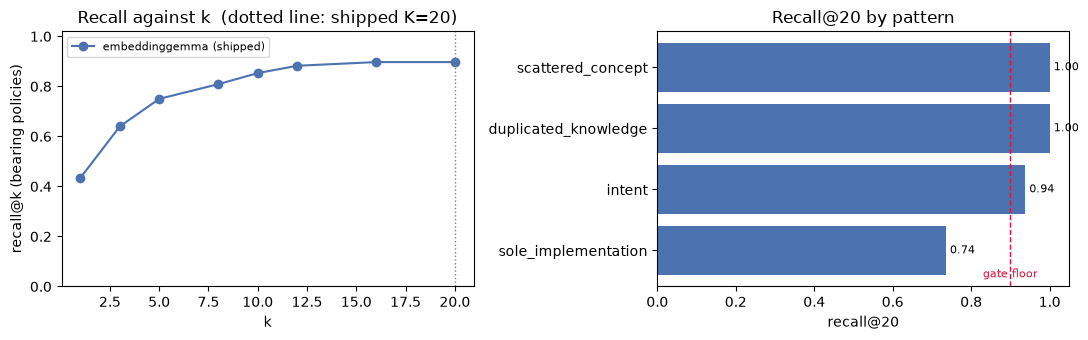

In [7]:
report.recall_charts(shipped, ks=KS)

Two things stand out.

Recall is flat from k=16 upward, so the shipped K=20 is already past the point where a wider
window buys anything.

And the loss is not spread evenly. `duplicated_knowledge` and `scattered_concept` candidates
are perfect at 1.00, while `sole_implementation` sits at 0.735, well under the gate's 0.90
per-pattern floor. Concentrated loss is a lead worth following, and section 4 follows it.

## 4. Where it misses

An aggregate says how much was missed, never what — and *what* is the only part anyone can
act on.

One distinction decides the whole response. If a right answer landed at **rank 22**, the
retriever understood the query and the window was two places too narrow; widening K fixes it.
If it landed at **rank 45 of 54**, the retriever never connected that query to that document,
and no window affordable inside a prompt would have reached it. The first is a parameter, the
second is a corpus problem.

Telling them apart needs the full ranking rather than the top twenty, so this section ranks
all 54 policies and reports where each missed policy actually came out.

In [8]:
misses = report.miss_table(shipped, cases)
print(f"{misses.index.nunique()} of {len(cases)} cases miss a bearing policy inside K=20")
display(misses)

14 of 68 cases miss a bearing policy inside K=20


,pattern,missed policy,true rank
case,,,
intent/interface-shaped-by-its-first-caller,intent,model-stable-concepts,22
intent/tax-rate-in-six-places,intent,avoid-duplicated-knowledge,22
intent/service-layer-forwards-everything,intent,prefer-deep-modules,32
intent/every-caller-repeats-the-same-six-lines,intent,prefer-deep-modules,32
"boundary-review/sole_implementation/Clock,SystemClock",sole_implementation,design-for-replaceability,33
"speech-vendor/sole_implementation/BookStore,SqliteBookStore",sole_implementation,design-for-replaceability,36
intent/mutable-settings-dict,intent,give-state-one-writer,38
"speech-vendor/sole_implementation/AudioSink,FileAudioSink",sole_implementation,design-for-replaceability,39
"boundary-review/sole_implementation/EmailSender,NotificationSender",sole_implementation,design-for-replaceability,40


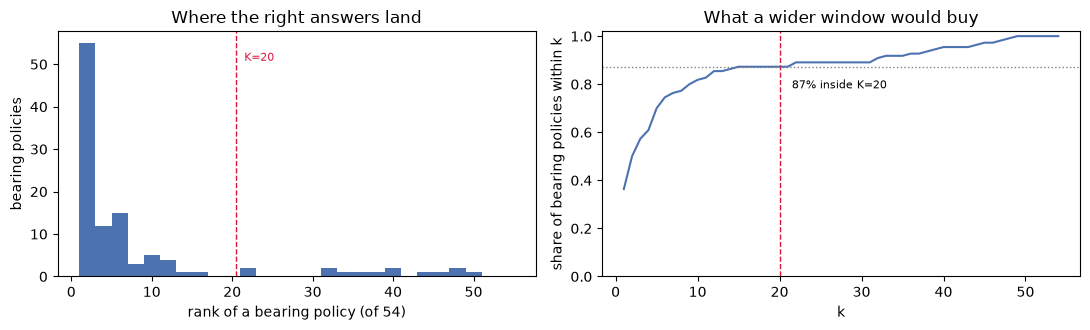

2 of 14 misses sit inside rank 30 — a wider window would find them.
12 sit below it, which no K reachable inside a prompt budget reaches.



,misses,median_rank
missed policy,,
design-for-replaceability,9,44.0
prefer-deep-modules,2,32.0
avoid-duplicated-knowledge,1,22.0
give-state-one-writer,1,38.0
model-stable-concepts,1,22.0


In [9]:
report.rank_charts(shipped, cases, corpus_size=len(corpus))

near = int((misses["true rank"] <= 30).sum())
print(f"{near} of {len(misses)} misses sit inside rank 30 — a wider window would find them.")
print(f"{len(misses) - near} sit below it, which no K reachable inside a prompt budget reaches.")
print()
display(
    misses.groupby("missed policy")
    .agg(misses=("pattern", "count"), median_rank=("true rank", "median"))
    .sort_values("misses", ascending=False)
)

**A single policy is nine of the fourteen misses.** `design-for-replaceability` fails on nine
different sole-implementation candidates, at a median rank of **44 out of 54** — near the
bottom of the corpus, for exactly the situation it was written to answer.

That deserves precision, because it is not a tuning problem. The policy argues from *cost to
remove*: narrow interfaces, owned data, internals that never leak. The query it is failing to
meet reads `implementations: 1`, `dependants_of_abstraction: 0`, "is implemented only by". A
person connects those instantly — the entire question about a port with one adapter is what it
would cost to replace. The embedding does not, and the reason is visible in the document: the
policy's `## Signals` section, which is the chunk a query like this would have to match, never
describes an abstraction with exactly one implementation.

So the fix is a sentence in a policy, not a constant in the retriever. And it is checkable:
add the sentence, re-run this notebook, watch rank 44 move.

The two remaining `prefer-deep-modules` misses at rank 32 are the same story in miniature.

## 5. Compared to what, and does the design pay?

A recall figure on its own is unreadable. 0.897 is excellent against a floor of 0.35 and
unremarkable against a plain keyword search that reaches 0.88 for free. So two reference
points, both run through the same interface as the real thing:

- **BM25** is the standard keyword ranking function — in short, it scores a document by how
  many of the query's words appear in it, weighting rare words more heavily and correcting
  for document length. It has no notion of meaning whatsoever. Left untuned on purpose: a
  baseline adjusted until it loses has stopped being a baseline.
- **Random** is a deterministic shuffle, seeded per query so a re-run reproduces it. With 54
  policies and about two right answers per case, drawing 20 finds roughly a third of them by
  luck — the floor any method has to clear before it has done anything at all.

Both index the same chunks and use the same "a policy scores as its best chunk" reduction, so
nothing but the ranking function differs between the three rows below.

,cases,R@1,R@3,R@5,R@8,R@10,R@12,R@16,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,,,,,
embeddinggemma (shipped),68,0.434,0.640,0.750,0.809,0.853,0.882,0.897,0.897,0.730,0.615,0.650,0.794
BM25 (lexical),68,0.368,0.522,0.640,0.735,0.779,0.809,0.831,0.853,0.614,0.524,0.565,0.721
random (floor),68,0.000,0.044,0.103,0.191,0.221,0.250,0.287,0.353,0.101,0.085,0.140,0.206


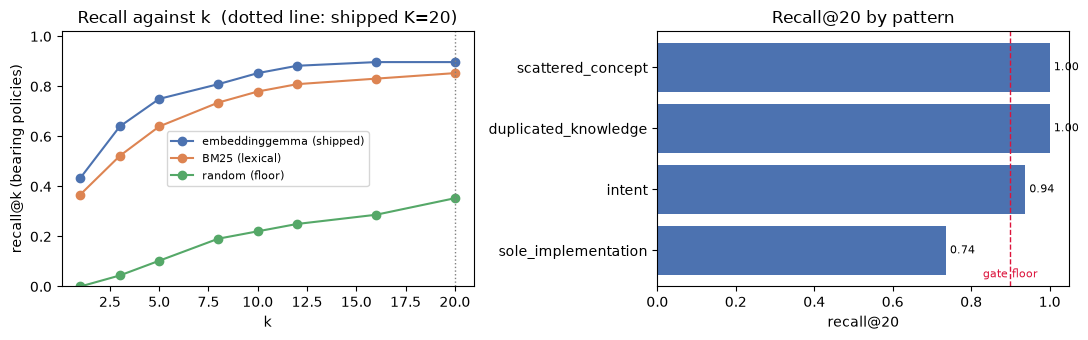

In [10]:
lexical = report.evaluate(Bm25PolicyIndex(), corpus, cases, label="BM25 (lexical)", ks=KS)
floor = report.evaluate(RandomPolicyIndex(), corpus, cases, label="random (floor)", ks=KS)

display(report.table(shipped, lexical, floor))
report.recall_charts(shipped, lexical, floor, ks=KS)

The embeddings beat keyword search everywhere, and the gap is widest at the top of the
ranking — R@1 0.434 against 0.368, MRR 0.730 against 0.614 — which is precisely the part a
prompt budget spends.

They are also not winning on word overlap. The intent cases are written in the problem's
vocabulary rather than the policy's, and they score **0.938** against **0.839** for the
candidate queries. A retriever leaning on shared words would show the opposite.

Now the two design choices the shipped index makes. Each is tested by changing that one thing
and holding everything else fixed.

**Task prompts.** EmbeddingGemma was trained with a prefix on every input saying what the text
is *for* — `task: search result | query: …` when embedding a search, `title: … | text: …` when
embedding a document to be found. The prefixes are how the model knows to place a short
question and the long answer to it in the same neighbourhood, instead of treating them as two
unlike texts. Ollama's modelfile for this model passes the prompt straight through, and
`build_embeddings` adds nothing, so the shipped path sends neither prefix.

**Chunking.** Nine vectors per policy instead of one, costing nine times the storage and nine
times the embedding calls when the index is built. The question is whether matching a
*section* beats matching a whole document.

In [11]:
prompted = InMemoryDenseIndex(
    TaskPrefixedEmbeddings(embeddings),
    embedding_identity=f"{IDENTITY}:prompted",
    dimensions=DIMENSIONS,
)
whole = InMemoryDenseIndex(
    embeddings,
    embedding_identity=f"{IDENTITY}:whole",
    dimensions=DIMENSIONS,
    chunker=whole_document_chunks,
)

display(
    report.table(
        shipped,
        report.evaluate(prompted, corpus, cases, label="+ task prompts", ks=KS),
        report.evaluate(whole, corpus, cases, label="whole documents", ks=KS),
        ks=(1, 5, 10, 20),
    )
)

,cases,R@1,R@5,R@10,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,
embeddinggemma (shipped),68,0.434,0.750,0.853,0.897,0.730,0.615,0.650,0.794
+ task prompts,68,0.463,0.757,0.838,0.897,0.775,0.635,0.660,0.809
whole documents,68,0.390,0.750,0.846,0.890,0.678,0.585,0.646,0.779


In [12]:
# The third choice: `retrieval_query` appends the case's constraints to every query. Only the
# 28 candidate cases have a case to strip, so this is scored on its own rather than mixed in.
with_case = candidate_cases(ROOT, with_constraints=True)
without_case = candidate_cases(ROOT, with_constraints=False)

display(
    report.table(
        report.evaluate(memory, corpus, with_case, label="with case constraints", ks=KS),
        report.evaluate(memory, corpus, without_case, label="without them", ks=KS),
        ks=(1, 5, 10, 20),
    )
)

,cases,R@1,R@5,R@10,R@20,MRR,MAP,nDCG@10,complete@20
variant,,,,,,,,,
with case constraints,28,0.232,0.643,0.786,0.839,0.660,0.465,0.603,0.679
without them,28,0.286,0.625,0.821,0.839,0.719,0.513,0.624,0.679


- **Task prompts help**, and specifically at the top of the ranking: R@1 0.434 → 0.463,
  MRR 0.730 → 0.775. The cost is two string formats. This is the one change here that could go
  into the product on the strength of a single run.
- **Heading chunks beat whole documents**, but modestly — R@1 0.434 against 0.390, MRR 0.730
  against 0.678, and effectively the same recall by k=20. Nine times the vectors buys
  precision at the top and nothing further down. Worth keeping, by a thinner margin than the
  storage cost would suggest.
- **The case constraints cost precision.** `retrieval_query` appends the case's constraints to
  every query — the one part of it a *user* writes. Doing so drops R@1 from 0.286 to 0.232 and
  MRR from 0.719 to 0.660, while recall@20 does not move at all. Constraint prose is about a
  third of the query text and pulls the top result away from the candidate's own shape without
  finding anything new lower down. This is the least comfortable result in the notebook, and
  28 cases is a thin basis for removing a user-facing input — it wants a second test set
  before anyone acts on it.

## 6. Does it pass the release gate?

`docs/policy-retrieval.md` sets conditions a retriever has to meet before its K and version
constants may move. It is a pass/fail check meant to run before a release, not a score.

This section runs the **whole shipped retriever**, not just the ranking, at each of the four K
values the gate evaluates. That distinction matters, because ranking is only half of what the
retriever does. The other half is a merge rule: a policy scoped to your organisation or your
repository, or marked *required*, goes into the prompt whatever the embeddings think of it.
The second cell checks that arm on its own.

The corpus grows by four policies here. Every one of the shipped 54 is general guidance, so
without them the merge rule would have nothing to include and the check would pass vacuously.

In [13]:
gate_index = InMemoryDenseIndex(
    embeddings, embedding_identity=f"{IDENTITY}:gate", dimensions=DIMENSIONS
)
gate_index.synchronize(full_corpus)

runs = {k: run_retriever(gate_index, full_corpus, with_case, top_k=k) for k in (8, 12, 16, 20)}
examples = {k: gate_examples(run, full_corpus) for k, run in runs.items()}

display(report.gate_table({k: evaluate_retrieval(v) for k, v in examples.items()}))

try:
    chosen, result = choose_smallest_passing_k(lambda k: examples[k])
    print(f"PASS — smallest passing K is {chosen} (macro recall {result.macro_recall:.3f})")
except ValueError as refusal:
    print(f"FAIL — {refusal}")

,macro recall,worst pattern,complete coverage,mandatory coverage,passes
K,,,,,
8,0.732,0.706,0.500,1.0,False
12,0.821,0.735,0.643,1.0,False
16,0.839,0.735,0.679,1.0,False
20,0.839,0.735,0.679,1.0,False
floor,0.950,0.900,0.750,1.0,True


FAIL — No evaluated dense top-K passes the retrieval gate (k=8: recall=0.732, coverage=0.500, k=12: recall=0.821, coverage=0.643, k=16: recall=0.839, coverage=0.679, k=20: recall=0.839, coverage=0.679)


In [14]:
# The mandatory arm on its own: every scoped or required policy that applies must be selected
# whatever the ranking says, and one that does not apply must never appear.
checks = [
    {
        "repository": case.repository,
        "policy": policy.id,
        "must be selected": (
            applies
            and (policy.scope.value != "general" or policy.strength.value == "required")
        ),
        "selected": policy.id in {item.id for item in retrieved.policies},
    }
    for case, retrieved in runs[20]
    for policy in scope_fixture
    for applies in [
        policy.applies_in(
            user=case.case.policy_context.user,
            organisation=case.case.policy_context.organisation,
            repository=case.case.policy_context.repository,
        )
    ]
]
scope_frame = pd.DataFrame(checks).assign(ok=lambda f: f["must be selected"] == f["selected"])

print(f"{int(scope_frame['ok'].sum())}/{len(scope_frame)} checks correct across "
      f"{scope_frame['repository'].nunique()} cases")
display(
    scope_frame.pivot_table(
        index="policy", columns="repository", values="selected", aggfunc="all"
    )
)
if not scope_frame["ok"].all():
    display(scope_frame[~scope_frame["ok"]])

112/112 checks correct across 5 cases


repository,acme-shop,audiobook-studio,boundary-review,speech-vendor,warehouse-sync
policy,,,,,
general-record-the-verdict,True,True,True,True,True
org-nightly-batch-window,False,False,False,False,False
org-vendor-adapter-boundary,True,True,False,True,False
repo-ledger-single-writer,False,False,False,False,True


It fails at every K, and not narrowly: macro recall tops out at 0.839 against a floor of 0.95,
and `sole_implementation` at 0.735 against 0.90.

A failing gate is not automatically a failing retriever. The gate scores the *bearing* set,
and that set is one person's judgement about what a reviewer would cite — a different labeller
would draw some of those lines differently. On the evidence in section 4, though, it is mostly
the retriever: nine of the misses are one policy that never comes close, which is not a
labelling disagreement.

The mandatory merge, meanwhile, is right in all 112 checks — every applicable scoped or
required policy selected, the one scoped to a different organisation never selected. That half
of the retriever needs no work.

**One gate condition is missing from the table.** `verdict_regression` asks whether the verdict
a model reaches on the twenty retrieved policies matches the verdict it reaches on all 54 — in
other words, whether shrinking the prompt changed the answer. Measuring it costs a
reasoning-model call per candidate per K, which nothing offline can pay, so the column is left
out rather than filled with a zero that would read as a pass. A K could clear everything above
and still change verdicts.

## 7. What it costs

Retrieval runs once per candidate, on the request path, while somebody waits.

In [15]:
sample = [case.query for case in cases[:20]]

timings = []
for query in sample:
    started = time.perf_counter()
    production.search(query, limit=20)      # no query cache, so each pays for its own embed
    timings.append(time.perf_counter() - started)
end_to_end = pd.Series(timings)

started = time.perf_counter()
for query in sample:
    memory.search(query, limit=20)          # already embedded, so this is the scan alone
scan = (time.perf_counter() - started) / len(sample)

median = end_to_end.median()
display(
    pd.DataFrame(
        [
            ("build the index", f"{corpus_embed:.0f} s",
             f"{chunks.chunks} chunks, once per corpus edit"),
            ("one retrieval, median", f"{median * 1000:.0f} ms",
             "embed the query, then scan"),
            ("one retrieval, p95", f"{end_to_end.quantile(0.95) * 1000:.0f} ms", ""),
            ("  the scan alone", f"{scan * 1000:.1f} ms", f"{scan / median:.1%} of it"),
            ("  the embedding call", f"{(median - scan) * 1000:.0f} ms",
             "the whole cost, effectively"),
            ("a review with 8 candidates", f"{8 * median:.1f} s", "with the index warm"),
        ],
        columns=["", "time", "note"],
    ).set_index("")
)

,time,note
,,
build the index,9 s,"486 chunks, once per corpus edit"
"one retrieval, median",127 ms,"embed the query, then scan"
"one retrieval, p95",139 ms,
the scan alone,0.8 ms,0.6% of it
the embedding call,126 ms,"the whole cost, effectively"
a review with 8 candidates,1.0 s,with the index warm


Almost all of it is the call to the embedding model. The similarity search over 486 vectors is
a rounding error beside it.

That rules out a whole category of optimisation. When vector search is slow the usual answer is
an approximate nearest-neighbour index, which trades exactness for speed — here it would buy
nothing, because the exact search is already free at this corpus size. If retrieval needs to be
faster, the embedding call is the only thing worth attacking.

## 8. Results on disk

`case-scores.csv` and `variant-summary.csv` are the evidence behind every table above — one
row per case per variant, so a number in this notebook can be traced to the case that produced
it. `evaluation.yaml` is the file `archcompass retrieval evaluate --from` reads, so the gate in
section 6 can be re-checked from a shell without opening a kernel.

In [16]:
variants = [shipped, lexical, floor]

pd.DataFrame(
    [
        {"variant": item.label, "case": score.case_id, "kind": score.kind,
         "pattern": score.pattern,
         **{f"R@{k}": value for k, value in score.bearing_recall_at_k},
         "MRR": score.reciprocal_rank, "AP": score.average_precision,
         "nDCG@10": score.ndcg_at_10, "missed@20": ", ".join(score.missed_at_20)}
        for item in variants
        for score in item.scores
    ]
).to_csv(RESULTS / "case-scores.csv", index=False)

report.table(*variants).to_csv(RESULTS / "variant-summary.csv")

(RESULTS / "evaluation.yaml").write_text(
    yaml.safe_dump(
        {
            "embedding_identity": IDENTITY,
            "results": {
                k: [
                    {"pattern": e.pattern,
                     "expected_policy_ids": sorted(e.expected_policy_ids),
                     "selected_policy_ids": list(e.selected_policy_ids),
                     "required_policy_ids": sorted(e.required_policy_ids),
                     "scoped_policy_ids": sorted(e.scoped_policy_ids)}
                    for e in items
                ]
                for k, items in examples.items()
            },
        },
        sort_keys=False,
    ),
    encoding="utf-8",
)

(RESULTS / "summary.json").write_text(
    json.dumps(
        {
            "embedding_identity": IDENTITY,
            "corpus_policies": len(corpus),
            "corpus_chunks": chunks.chunks,
            "cases": len(cases),
            "recall_at_k": dict(shipped.summary.recall_at_k),
            "mrr": shipped.summary.mrr,
            "map": shipped.summary.map_score,
            "ndcg_at_10": shipped.summary.ndcg_at_10,
            "recall_by_pattern": dict(shipped.summary.recall_by_pattern),
            "gate_passes": any(evaluate_retrieval(v).passed for v in examples.values()),
            "corpus_embed_seconds": corpus_embed,
            "retrieval_seconds_median": float(median),
        },
        indent=2,
    ),
    encoding="utf-8",
)

for path in sorted(RESULTS.glob("*")):
    if path.suffix != ".sqlite3":
        print(f"{path.relative_to(ROOT)}  {path.stat().st_size:,} bytes")
print()
print("uv run archcompass retrieval evaluate --from evaluation/results/evaluation.yaml")

evaluation/results/case-scores.csv  35,839 bytes
evaluation/results/evaluation.yaml  83,023 bytes
evaluation/results/retrieval-evaluation.html  559,019 bytes
evaluation/results/summary.json  738 bytes
evaluation/results/variant-summary.csv  349 bytes

uv run archcompass retrieval evaluate --from evaluation/results/evaluation.yaml


---

## What this does not measure

- **Whether a smaller prompt changes the verdict.** The `verdict_regression` gate condition,
  which needs a reasoning model. Uncovered here, and the most important gap.
- **Disagreement about the right answer.** The bearing sets are one person's reading of what a
  reviewer would cite. `design-for-replaceability` in section 4 is exactly the kind of call
  another labeller might make differently, and the gate's verdict rests on calls like it.
- **Any other embedding model.** Nothing compares `embeddinggemma` against
  `gemini-embedding-2`, the hosted model the product defaults to. The harness would run it
  unchanged — swap `ollama_embeddings` for a Google `EmbeddingModelConfig` — but it spends API
  quota, so it stays out of the offline path.
- **Detector shapes that do not exist yet.** The candidate half of the set can only ask about
  the three patterns the detectors find. A new detector arrives here with no labels behind it.